In [1]:
#Applyling all the metrics on our data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())
print(os.listdir())

/Users/smritimishra/PycharmProjects/ML-Tutorials/06_modelling
['multiple_linear_regression.ipynb', 'grid_search.ipynb', 'linear_regression_intro.ipynb', 'placement.csv', 'regression_metrics.ipynb', 'linear_regression_math.ipynb']


In [3]:
print(os.listdir())  # you already did, no 'data' folder shown


['multiple_linear_regression.ipynb', 'grid_search.ipynb', 'linear_regression_intro.ipynb', 'placement.csv', 'regression_metrics.ipynb', 'linear_regression_math.ipynb']


In [4]:
df = pd.read_csv("../data/placement.csv")


In [5]:
print(df.head())


   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


In [6]:
df.shape


(200, 2)

In [7]:
print(df.sample(10))

     cgpa  package
123  5.10     2.30
33   6.35     2.73
113  6.94     2.37
43   7.66     2.76
10   5.32     1.86
38   8.62     4.36
66   5.11     1.63
39   7.43     3.33
59   7.56     3.31
153  7.94     3.99


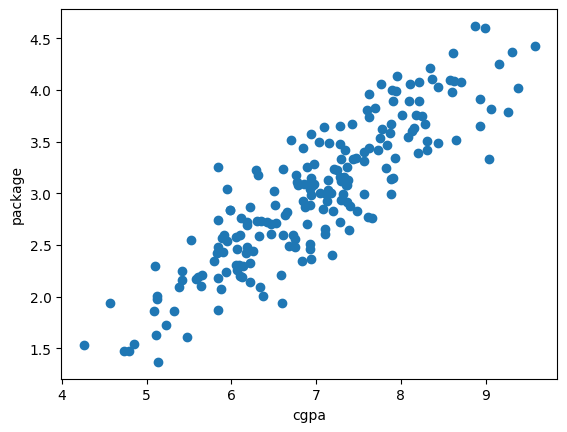

In [8]:
plt.scatter(df['cgpa'] ,df['package'])
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [9]:
x = df.iloc[: , 0:1]
y = df.iloc[:,-1]

In [45]:
print(x)


     cgpa  random_feature
0    6.89        0.010959
1    5.12        0.522092
2    7.82        0.865764
3    7.42        0.751895
4    6.94        0.226026
..    ...             ...
195  6.93        0.364065
196  5.89        0.035090
197  7.21        0.314499
198  7.63        0.834037
199  6.22        0.720031

[200 rows x 2 columns]


In [13]:
print(y)

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size =0.2 , random_state = 2)

In [16]:
from sklearn.linear_model import LinearRegression


In [17]:
lr = LinearRegression()


In [19]:
lr.fit(x_train , y_train)


LinearRegression()


In [20]:
y_pred = lr.predict(x_test)


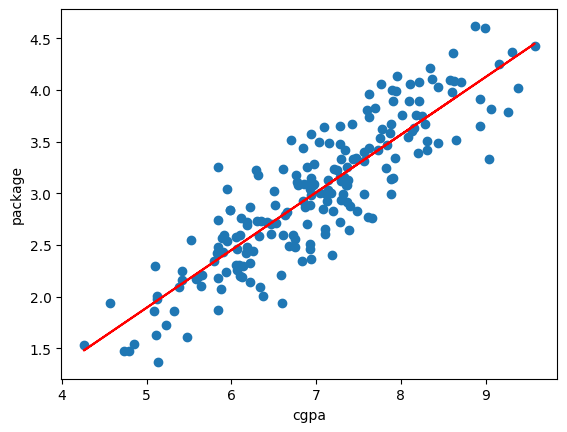

In [21]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(x_train , lr.predict(x_train), color = 'red')
plt.xlabel('cgpa')
plt.ylabel('package')
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [24]:
lr.predict(x_test)

array([3.89111601, 3.09324469, 2.38464568, 2.57434935, 1.6537286 ,
       1.77647803, 2.07219258, 2.93143862, 3.76278706, 2.93701814,
       4.09197872, 3.51170867, 2.97049525, 2.40138424, 3.18809652,
       3.46707251, 1.94386362, 3.24389172, 2.97607477, 3.41685683,
       2.55761079, 3.16577844, 2.85890486, 3.12114229, 3.68467378,
       2.8700639 , 3.49497011, 3.34432308, 3.91901361, 1.96060218,
       3.65119666, 3.2104146 , 3.74046898, 2.7863711 , 2.78079158,
       3.27178932, 3.52844723, 2.61340599, 2.65804215, 2.71383735])

In [26]:
y_test.values



array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [27]:
print("MAE" , mean_absolute_error(y_test,y_pred))
#unit of mae is lpa

MAE 0.2884710931878175


In [28]:
print("MSE :" , mean_squared_error(y_test , y_pred))
#unit not same as package


MSE : 0.12129235313495527


In [29]:
print("RMSE :" , np.sqrt(mean_squared_error(y_test ,y_pred)) )
#unit of rmse is in lpa

RMSE : 0.34827051717731616


In [30]:
print("r2score" , r2_score(y_test , y_pred))
#not very great but not too bad either


r2score 0.780730147510384


In [32]:
#Adjusted r2 score
r2 =  r2_score(y_test , y_pred)
1-((1 - r2)*(40-1))/(40 -1-1)


0.7749598882343415

In [35]:
df.shape

(200, 2)

In [39]:
#proving that adjusted r2 score lowers its value when an irrelevant column is added .

newdf = df.copy()
newdf['random_feature'] = np.random.random(200)

newdf = newdf[['cgpa', 'random_feature' ,'package']]


In [41]:
print(newdf.head())


   cgpa  random_feature  package
0  6.89        0.010959     3.26
1  5.12        0.522092     1.98
2  7.82        0.865764     3.25
3  7.42        0.751895     3.67
4  6.94        0.226026     3.57


Text(0, 0.5, 'package(in lpa')

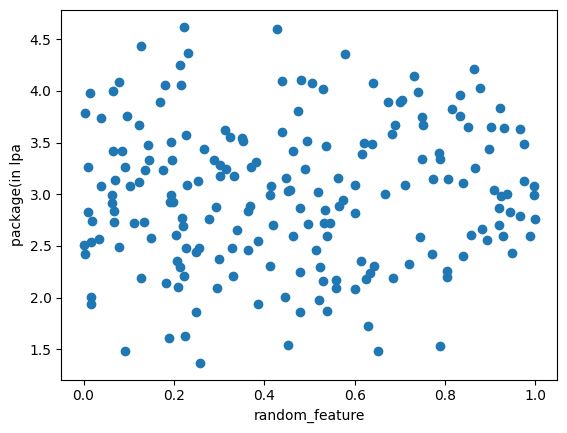

In [56]:
plt.scatter(newdf['random_feature'], newdf['package'])
plt.xlabel('random_feature')
plt.ylabel('package(in lpa')

In [44]:
x = newdf.iloc[:,0:2]
y = newdf.iloc[:,-1]

In [48]:
x_train , x_test, y_train , y_test = train_test_split(x, y , test_size = 0.2 , random_state = 2)

In [49]:
lr = LinearRegression()

In [50]:
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.56,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.9022
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [52]:
y_pred2 = lr.predict(x_test)

In [53]:
print("new r2 score :" , r2_score(y_test , y_pred2))

new r2 score : 0.7811753341000399


In [54]:
x_test.shape

(40, 2)

In [57]:
newr2 = r2_score(y_test , y_pred2)
1- ((1-newr2)*(40-1))/(40-1-2)

0.7693469737811232

In [60]:
#now doing the same process to prove that adjusted r2score increases its value on adding a relevant column is added

newdf2 = df.copy()
newdf2['iq'] = df['package'] +(np.random.randint(-12 , 12 , 200)/10)
newdf2 = newdf2[['cgpa', 'iq' , 'package']]

In [62]:
print(newdf2.head())


   cgpa    iq  package
0  6.89  4.16     3.26
1  5.12  1.18     1.98
2  7.82  2.05     3.25
3  7.42  3.17     3.67
4  6.94  2.87     3.57


In [63]:
x = newdf2.iloc[:, 0:2]
y = newdf2.iloc[:,-1]

In [64]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2 , random_state = 2)

In [65]:
lr = LinearRegression()

In [66]:
lr.fit(x_train , y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.47,0.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.7872
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [67]:
y_pred = lr.predict(x_test)


In [68]:
#calculating r2 score
print("r2score:" , r2_score(y_test , y_pred))

r2score: 0.8102093966486983


In [69]:
x_test.shape

(40, 2)

In [70]:
#adjusted r2 score
newr2 = r2_score(y_test , y_pred)
1- (((1-newr2)*(40-1))/(40-1-2))

0.7999504451161955